In [19]:
from traceback import print_tb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from numpy.ma.core import ravel

In [1]:
#scikit learn
import seaborn as sns
from matplotlib import pyplot as plt

iris = sns.load_dataset('iris')
print(iris.head())
print(type(iris))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.DataFrame'>


<class 'tuple'>
<class 'pandas.Index'>
<class 'pandas.RangeIndex'>


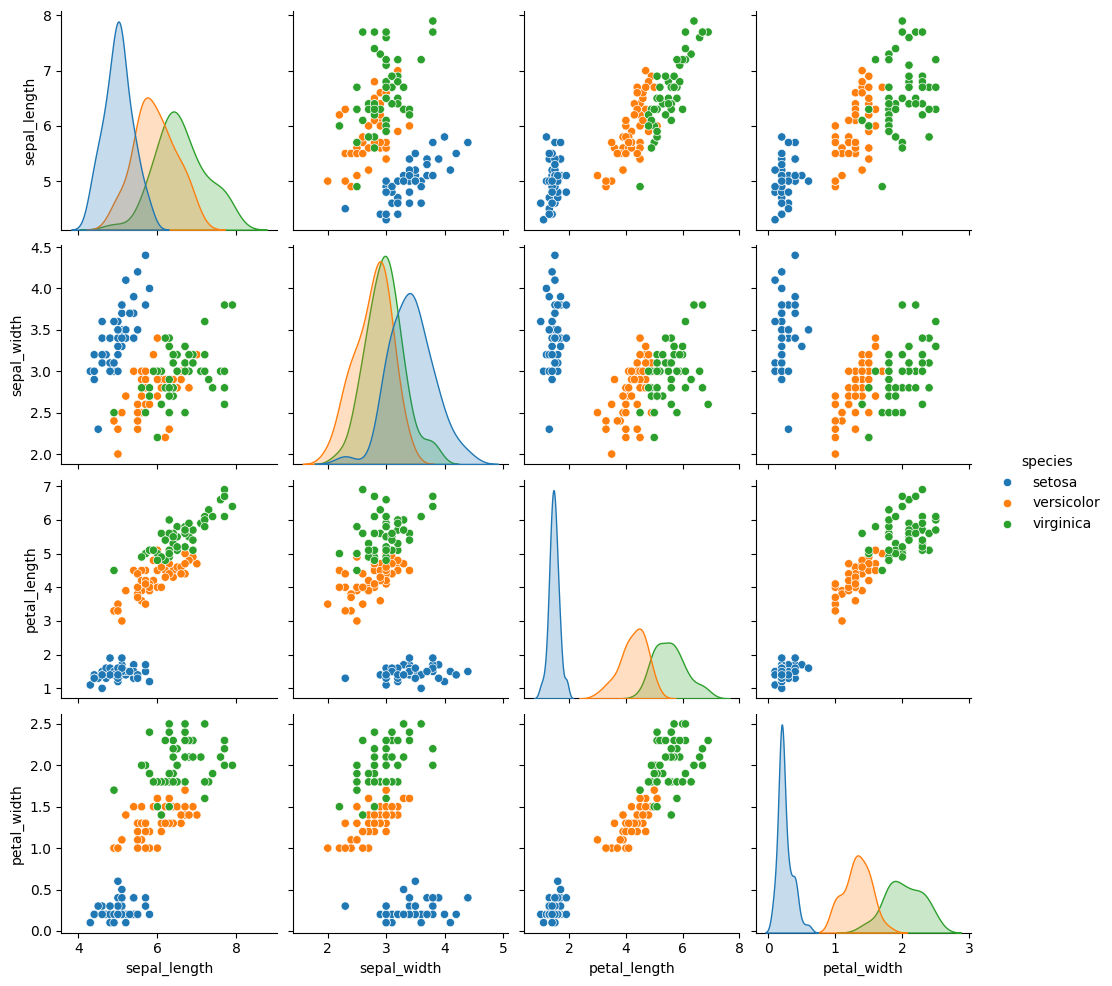

In [8]:
print(type(iris.values.shape))
print(type(iris.columns))
print(type(iris.index))
sns.pairplot(iris, hue='species')
plt.show()

In [ ]:
# Строки - образцы данных - отдельный объект (sample)
# столбцы - признаки (features)
# Матрица признаков [число образцов. число признаков] - независимая переменная
# Целевой массив (target/label) [1 на число признаков] - зависимая переменная

In [11]:
X_iris = iris.drop('species', axis=1)
# print(X_iris.head())

Y_iris = iris['species']
# print(Y_iris.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str


In [15]:
# С учителем, Реггрессия, Линейная
x = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()
print(x)
print(y)

[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
 5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
 5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5. ]
[3.5 3.  3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 3.7 3.4 3.  3.  4.  4.4 3.9 3.5
 3.8 3.8 3.4 3.7 3.6 3.3 3.4 3.  3.4 3.5 3.4 3.2 3.1 3.4 4.1 4.2 3.1 3.2
 3.5 3.6 3.  3.4 3.5 2.3 3.2 3.5 3.8 3.  3.8 3.2 3.7 3.3]


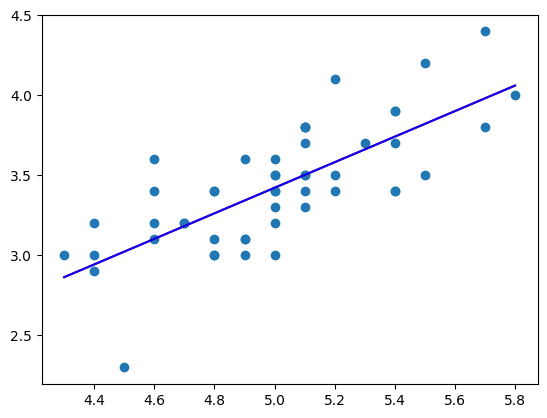

In [28]:
# 1. Выбирается класс модели
from sklearn.linear_model import LinearRegression

# 2. Если надо, выбираются гиперпараметры модели(не зависят от параметров)
model = LinearRegression(fit_intercept=True)

# 3. На основе данных создается матрица признаков и целевой вектор
# x = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy() - матрица
# y = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy() - вектор

# 4. Обучение модели fit()
reg = model.fit(x[:, np.newaxis], y)
plt.scatter(x, y)

# 5. Обученная модель применяется к новым данным
#   5.1 Обучение с учителем - predict()
#   5.2 Обучение без учителя - predict() или transform()
xfit = np.linspace(x.min(), x.max(), 1000)
yfit = model.predict(xfit[:, None])
plt.plot(xfit, yfit, color='red')
plt.plot(xfit, xfit * reg.coef_ + reg.intercept_, color='blue' )
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

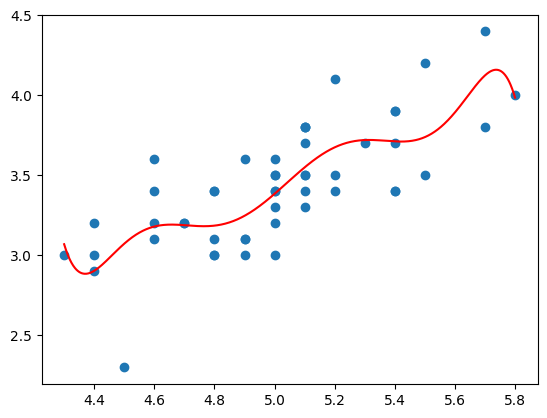

In [33]:
# Полиномиальная регрессия
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

model = make_pipeline(PolynomialFeatures(7), LinearRegression())
reg = model.fit(x[:, np.newaxis], y)

xfit = np.linspace(x.min(), x.max(), 1000)
yfit = model.predict(xfit[:, None])

# plt.scatter(x, y)
# plt.plot(xfit, yfit, color='red')
# plt.show

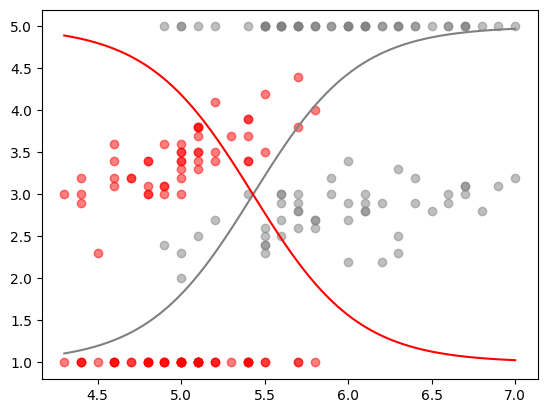

In [49]:
# Классификация. Логистическая регрессия
x_0 = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
y_0 = iris[iris['species'] == 'setosa'].iloc[:, 1].to_numpy()
x_1 = iris[iris['species'] == 'versicolor'].iloc[:, 0].to_numpy()
y_1 = iris[iris['species'] == 'versicolor'].iloc[:, 1].to_numpy()

plt.scatter(x_0, y_0, alpha=0.5, color='red')
plt.scatter(x_1, y_1, alpha=0.5, color='grey')

x_00 = iris[iris['species'] == 'setosa'].iloc[:, 0].to_numpy()
x_11 = iris[iris['species'] == 'versicolor'].iloc[:, 0].to_numpy()
plt.scatter(x_00, np.full(50,1), alpha=0.5, color='red')
plt.scatter(x_1, np.full(50,5), alpha=0.5, color='grey')


from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

x = iris[iris['species'] != 'virginica'].iloc[:, 0].to_numpy()
y = iris[iris['species'] != 'virginica'].iloc[:, 4].to_numpy()
model.fit(x[:, np.newaxis], y)

xfit = np.linspace(x.min(), x.max(), 1000)
yfit = model.predict_proba(xfit[:, None])

plt.plot(xfit, 1 + 4 * yfit[:, 1], color='grey')
plt.plot(xfit, 1 + 4 * yfit[:, 0], color='red')

plt.show()

[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]
 [ 5 50]]
[ 1  2  3  4  5 10 20 30 40 50]


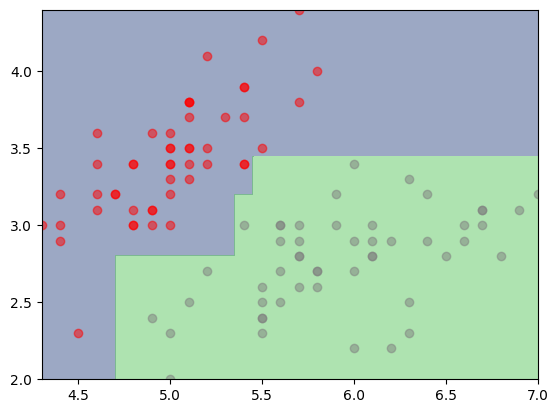

In [64]:
# Деревья решений
from sklearn.tree import DecisionTreeClassifier

x = iris[iris['species'] != 'virginica'].iloc[:, 0:2].to_numpy()
y = iris[iris['species'] != 'virginica'].iloc[:, 4]
y1 = np.full(50,1)
y2 = np.full(50,2)
y = np.ravel([y1, y2])

tree = DecisionTreeClassifier(max_depth=7)
tree = tree.fit(x, y)

print(np.c_[[1,2,3,4,5],[10,20,30,40,50]])
print(np.ravel([[1,2,3,4,5],[10,20,30,40,50]]))

xx, yy = np.meshgrid(
    np.linspace(x[:, 0].min(), x[:, 0].max(), 1000),
    np.linspace(x[:, 1].min(), x[:, 1].max(), 1000)
)

Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax = plt.gca()
ax.contourf(xx, yy, Z, alpha=0.5, levels=[0,1.5,3])

plt.scatter(x_0, y_0, alpha=0.5, color='red')
plt.scatter(x_1, y_1, alpha=0.5, color='grey')


plt.show()